In [1]:
import numpy as np
from scipy.io import wavfile

import matplotlib.pyplot as plt


def plot_wav(wav_path: str, channel: int = 0, ax=None):
    """
    Plot a .wav file waveform.

    Parameters
    ----------
    wav_path : str
        Path to the .wav file.
    channel : int, default=0
        Channel index for multi-channel audio.
    ax : matplotlib.axes.Axes, optional
        Existing axis to draw on.

    Returns
    -------
    ax : matplotlib.axes.Axes
        Axis with the waveform plot.
    """
    sample_rate, data = wavfile.read(wav_path)

    # Select one channel if audio is multi-channel
    if data.ndim > 1:
        if channel < 0 or channel >= data.shape[1]:
            raise ValueError(f"Invalid channel {channel}. Available: 0..{data.shape[1]-1}")
        y = data[:, channel]
    else:
        y = data

    # Time axis in seconds
    t = np.arange(len(y)) / sample_rate

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))

    ax.plot(t, y, linewidth=0.8)
    ax.set_title(f"Waveform: {wav_path}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.3)

    return ax


In [2]:
import pandas as pd

df = pd.read_csv("/Users/adityakumar/Developer/Projects/emodb_project/data/csv/segments.csv")
df.iloc[0]


ID                                                  03a01Fa_1
duration                                               1.8982
wav         /Users/adityakumar/Developer/Projects/emodb_pr...
spk_id                                                      3
label                                                       0
Name: 0, dtype: object

1.8982
1.6113
1.8778
1.0031
1.0031
1.4398
1.7357
1.0618
1.0618
1.4981


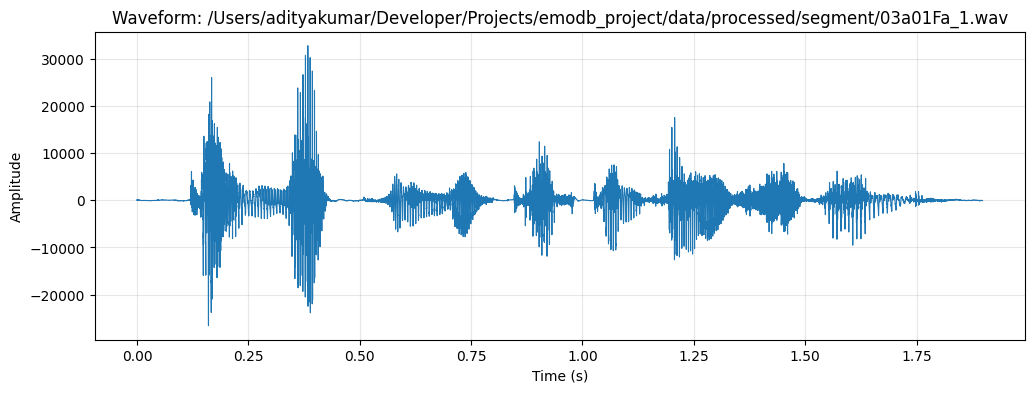

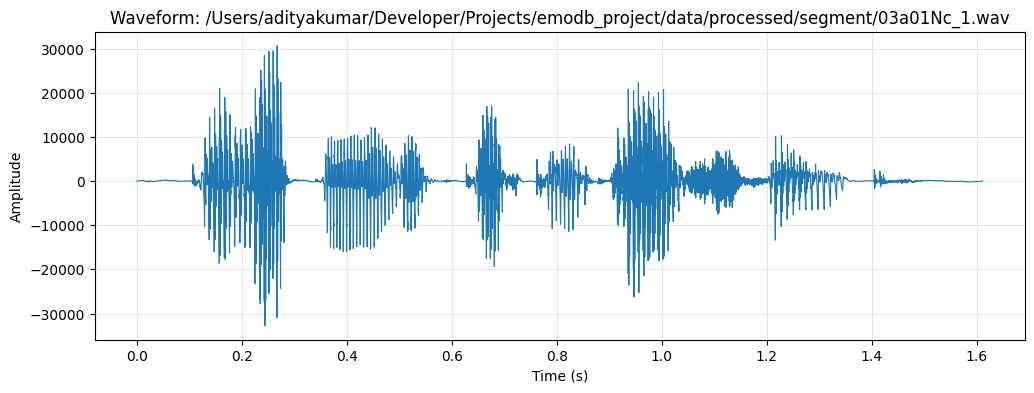

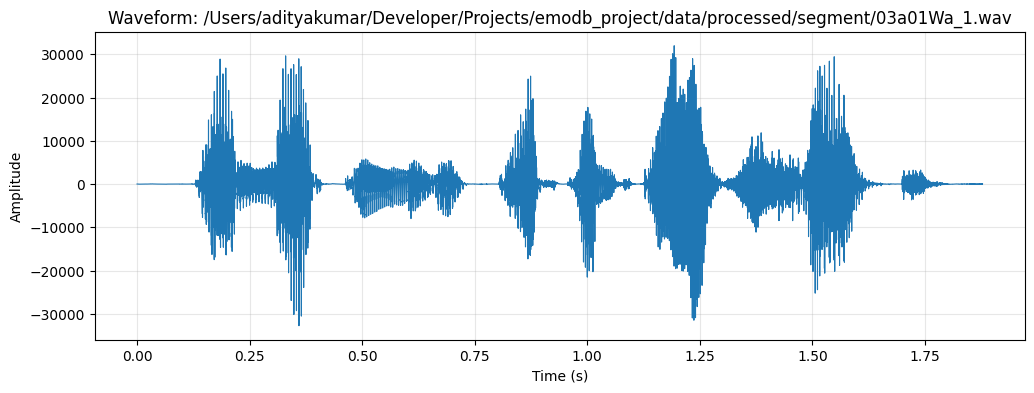

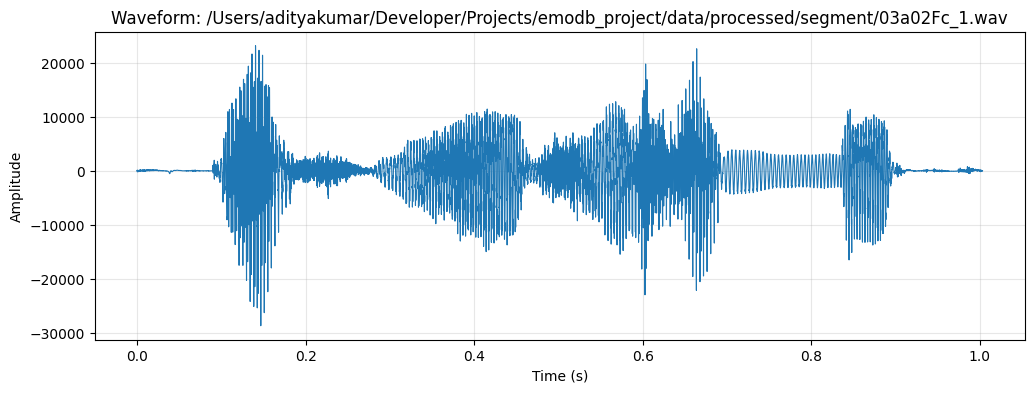

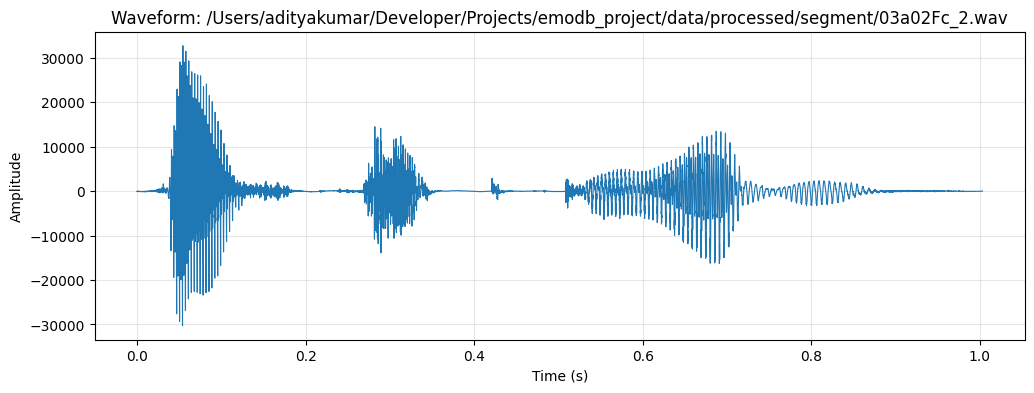

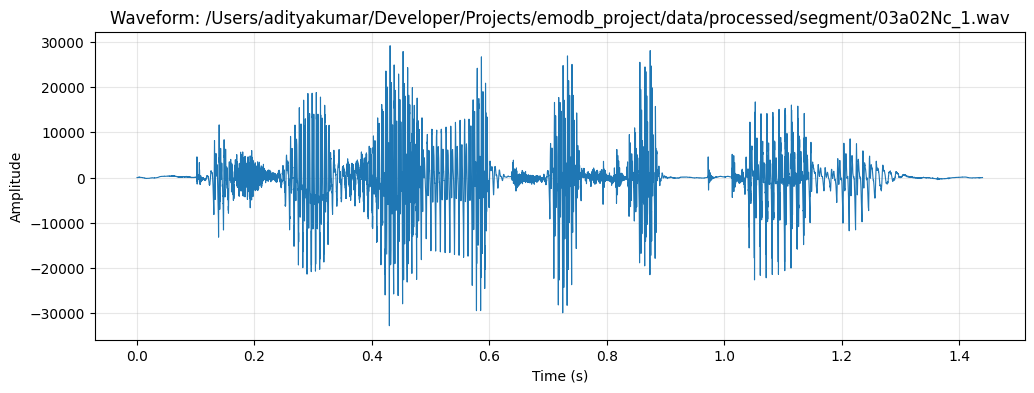

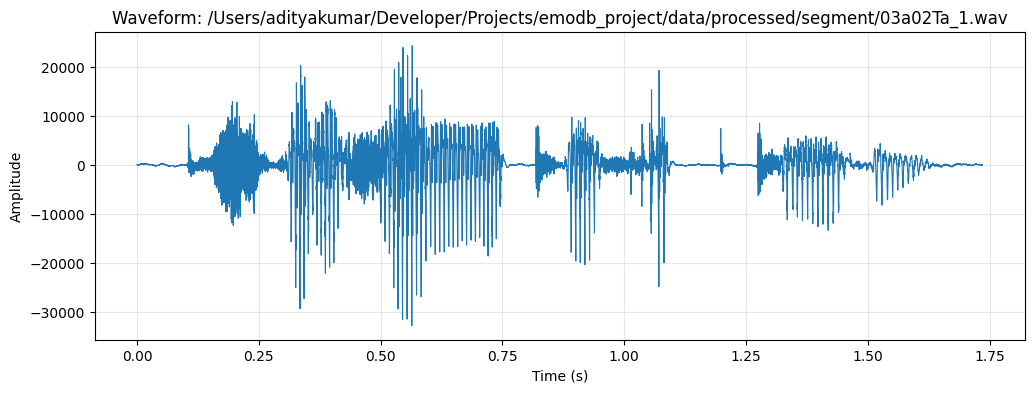

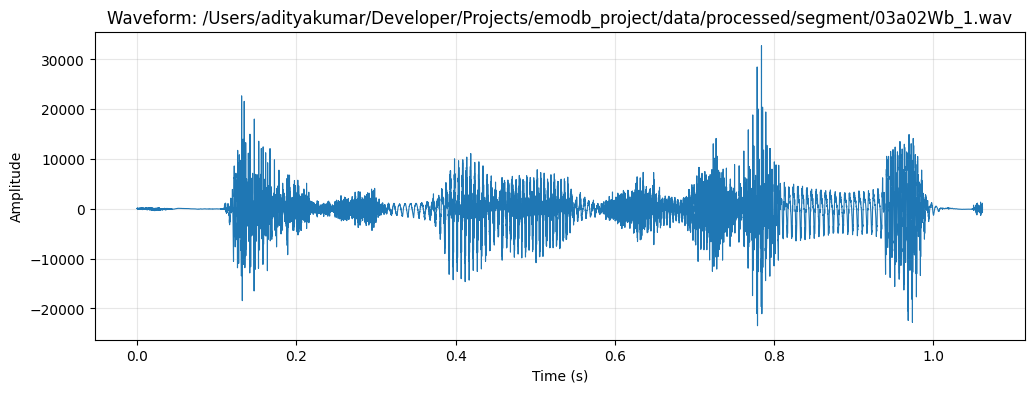

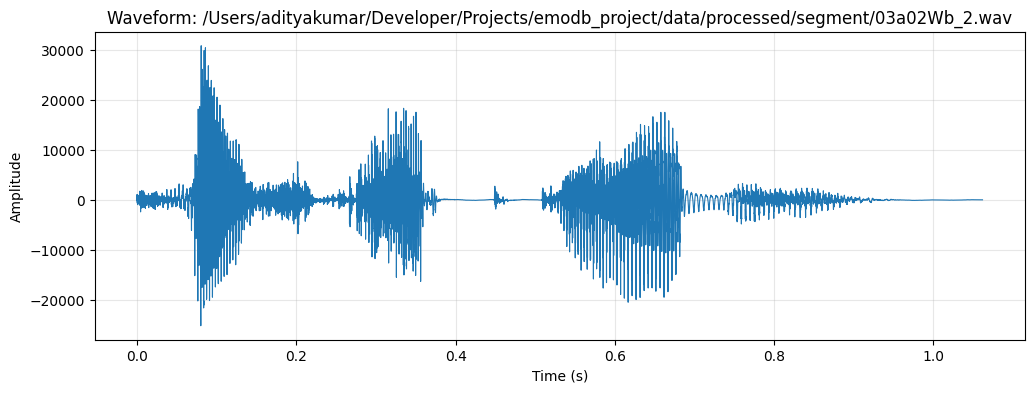

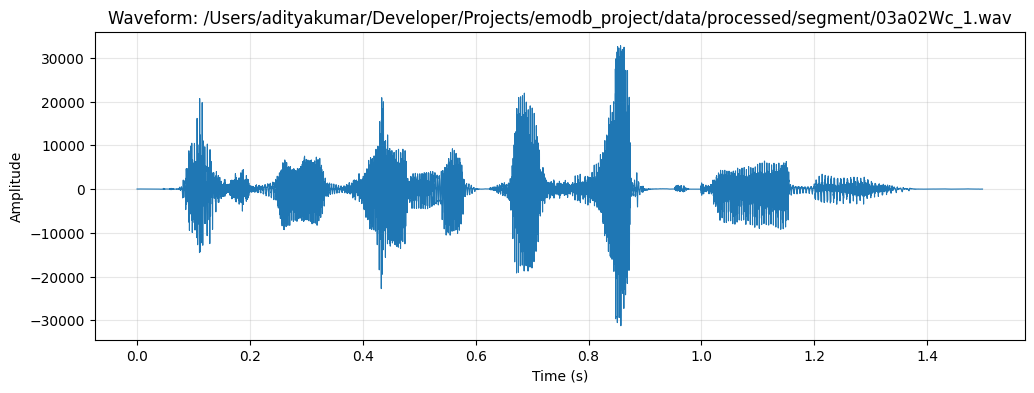

In [3]:
for i in range(10):
    plot_wav(df.iloc[i].wav)
    print(df.iloc[i].duration)


In [ ]:
import librosa

import librosa.display

# Use existing row index `i` and dataframe `df`
wav_path = df.iloc[0].wav

# Load audio
y, sr = librosa.load(wav_path, sr=None, mono=True)

# Compute MFCCs
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

# Visualize
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, sr=sr, x_axis="time")
plt.colorbar(format="%+2.0f dB")
plt.title(f"MFCC (n_mfcc=13)\n{df.iloc[i].ID}")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()
plt.show()


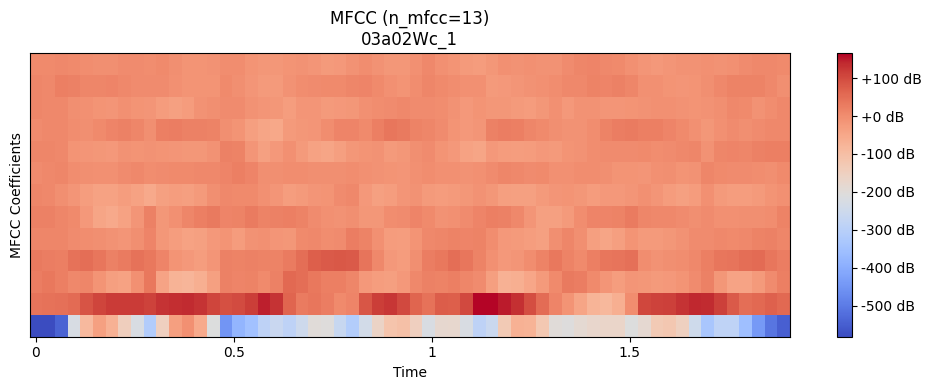

In [4]:
import librosa

import librosa.display

# Use existing row index `i` and dataframe `df`
wav_path = df.iloc[0].wav

# Load audio
y, sr = librosa.load(wav_path, sr=None, mono=True)

# Compute MFCCs
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

# Visualize
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, sr=sr, x_axis="time")
plt.colorbar(format="%+2.0f dB")
plt.title(f"MFCC (n_mfcc=13)\n{df.iloc[i].ID}")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()
plt.show()
